# Simulation for Multiprocessing Upload

Testing single-thread versus multiprocessing upload considering different types of file sizes representing chunks of a large data-frame.

## Setting up the experiment

In [22]:
from pyscora_wrangler.transform import to_parquet
from pyscora_wrangler.utils import overwrite_folder
import os
import pandas as pd
import numpy as np
from time import time
import matplotlib.pyplot as plt
import seaborn as sns
import boto3

from pyscora_wrangler.upload import (
    mp_folder_s3_upload,
    upload_file_s3
)

## Setting up the experiment

In [23]:
def generate_chunks(chunksize):
    stream = pd.read_csv('test_data/input/MICRODADOS_ENEM_2019.csv',
                        delimiter=';',
                        chunksize=chunksize)
    overwrite_folder('test_data/output')
    to_parquet(stream,
            output_parquet='test_data/output',
            multiple_files=True)

In [24]:
def get_mean_of_files_size_mb(folder):
    size_of_files_mb = []
    n = 0
    for f in os.listdir(folder):
        file_stats = os.stat(os.path.join(folder, f))
        size_of_files_mb.append( file_stats.st_size / (1024 * 1024) )
        n+=1
    size_of_files_mb = np.array(size_of_files_mb)

    return n, size_of_files_mb.mean()
get_mean_of_files_size_mb('test_data/output')

(102, 6.296214141097724)

In [25]:
def single_thread_upload_time(boto3_client):
    local_folder = 'test_data/output'
    s3_folder = 's3://oncase-test-data/ENEM_2019/output/single-thread'
    files = os.listdir(local_folder)
    files = [os.path.join(local_folder, i) for i in files]

    t0 = time()
    for f in files:
        tail_of_filename = os.path.split(f)[1]
        s3_filepath = s3_folder + '/' + tail_of_filename
        upload_file_s3(f, s3_filepath, boto3_client)
    t1 = time()
    return t1-t0

def multi_processing_upload_time():
    t0 = time()
    mp_folder_s3_upload(folder_path='test_data/output',
                        s3_folder_path='s3://oncase-test-data/ENEM_2019/output/multi-processing')
    t1 = time()
    return t1 - t0


## Experiment

### Size of the original file

In [26]:
file_stats = os.stat('test_data/input/MICRODADOS_ENEM_2019.csv')
print(f"File size in MB: {file_stats.st_size / (1024 * 1024)}")

File size in MB: 3050.760993003845


In [27]:
boto3_client = boto3.client('s3')

chunksize_list = [1000000,500000, 100000, 50000, 25000, 10000, 1000]

mean_size_of_files_mb = []
n_chunks = []
time_of_single_thread = []
time_of_multiprocessing = []
for chunksize in chunksize_list:
    generate_chunks(chunksize)
    print(f'Generated {chunksize}')

    n, mu_size = get_mean_of_files_size_mb('test_data/output')
    mean_size_of_files_mb.append(mu_size)
    n_chunks.append(n)
    print(f"{n} number of files, {mu_size} mean size in MB")

    st = single_thread_upload_time(boto3_client)
    time_of_single_thread.append(st)
    print(f'Time of Single-Thread upload: {st}')

    mp = multi_processing_upload_time()
    time_of_multiprocessing.append(mp)
    print(f"Time of multiprocessing upload: {mp}")
    

Generated 500000
11 number of files, 55.48005823655562 mean size in MB
Time of Single-Thread upload: 171.05374360084534
Time of multiprocessing upload: 120.7417345046997
Generated 100000
51 number of files, 12.304288228352865 mean size in MB
Time of Single-Thread upload: 270.89462637901306
Time of multiprocessing upload: 152.73262763023376
Generated 50000
102 number of files, 6.296214141097724 mean size in MB
Time of Single-Thread upload: 292.42092084884644
Time of multiprocessing upload: 182.27016401290894
Generated 25000
204 number of files, 3.2793050607045493 mean size in MB
Time of Single-Thread upload: 388.06306433677673
Time of multiprocessing upload: 182.25223112106323
Generated 10000
510 number of files, 1.396776835123698 mean size in MB
Time of Single-Thread upload: 542.1745867729187
Time of multiprocessing upload: 199.77225947380066
Generated 1000
5096 number of files, 0.23378322599821225 mean size in MB
Time of Single-Thread upload: 2492.2762501239777
Time of multiprocessing

In [38]:
df = pd.DataFrame({
    'n_file': n_chunks,
    'chunksize': chunksize_list,
    'mean_filesize': mean_size_of_files_mb,
    'time_single_thread': time_of_single_thread,
    'time_multiprocessing': time_of_multiprocessing
})
df

,n_file,chunksize,mean_filesize,time_single_thread,time_multiprocessing
0,11,500000,55.480058,171.053744,120.741735
1,51,100000,12.304288,270.894626,152.732628
2,102,50000,6.296214,292.420921,182.270164
3,204,25000,3.279305,388.063064,182.252231
4,510,10000,1.396777,542.174587,199.772259
5,5096,1000,0.233783,2492.276250,1031.750694


In [39]:
df.to_csv("simulation_data.csv")

<AxesSubplot:xlabel='chunksize', ylabel='value'>

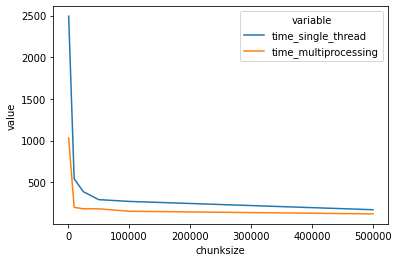

In [37]:
df_plot = pd.melt(df, id_vars=['chunksize'], value_vars=['time_single_thread', 'time_multiprocessing'])
sns.lineplot(x="chunksize", y="value",
             hue="variable",
             data=df_plot)

<AxesSubplot:xlabel='n_file', ylabel='value'>

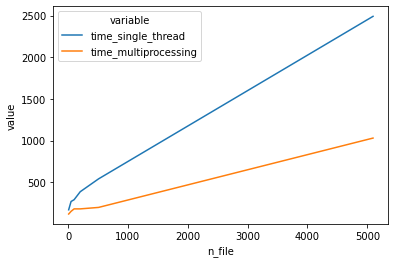

In [41]:
df_plot = pd.melt(df, id_vars=['n_file'], value_vars=['time_single_thread', 'time_multiprocessing'])
sns.lineplot(x="n_file", y="value",
             hue="variable",
             data=df_plot)